# Spectral Filter Optimization — Proxy Design + Learned Reconstruction

Notebook version of `scripts/spectral_filter_optimization_example.py`.  This example
optimizes a small **multi-channel spectral filter bank** (implemented as an amplitude mask)
for spectral sensing, then trains an MLP to reconstruct spectra from the resulting optical
measurements.

The workflow has two stages:

1. **Proxy filter optimization** using a PCA/Fisher-information objective (`D`-optimality),
   which is much cheaper than training a reconstruction network inside the loop.
2. **End-to-end reconstruction training** of an MLP decoder, with optional measurement noise,
   while continuing to refine the filter bank.

### Outline

1. **Imports** and dependencies (JAX, Flax, PCA, fouriax optics).
2. **MLP decoder** used for spectral reconstruction.
3. **Data + helper utilities** (Indian Pines subset, PCA basis, filter parametrization).
4. **Optical measurement model** (detector masks and amplitude-mask sensing).
5. **PCA-space proxy objective** used for fast filter pre-optimization.
6. **Repository root resolution**.
7. **Experiment configuration**.
8. **Data loading + proxy optimizer setup**.
9. **Proxy optimization loop**.
10. **Reconstruction model setup** and noisy measurement decoder.
11. **Reconstruction training loop**.
12. **Final evaluation metrics**.
13. **Inline plots** and saved overview figure.


## 1  Imports

This notebook combines numerical optimization (`jax`, `optax`), neural-network modeling
(`flax.linen`), dimensionality reduction (`sklearn.decomposition.PCA`), and an optical
measurement model built with `fouriax.optics`.

The optical portion is intentionally simple: an `AmplitudeMask` plus an `IntensitySensor`
with detector masks.  The complexity comes from the spectral design objective and the
reconstruction model.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Sequence

import jax
import jax.numpy as jnp
import numpy as np
import optax
from flax import linen as nn
from sklearn.decomposition import PCA

from fouriax.optics import AmplitudeMask, Field, Grid, IntensitySensor, OpticalModule, Spectrum

%matplotlib inline

## 2  MLP Decoder Model

`SpectralReconMLP` maps the optical measurement vector $y \in \mathbb{R}^K$ (one value per
filter/detector channel) back to an estimated spectrum $\hat{x} \in \mathbb{R}^L$.

In this example, the MLP is used after proxy filter optimization and then trained jointly
with the filter parameters during the reconstruction stage.


In [2]:

class SpectralReconMLP(nn.Module):
    hidden_dims: Sequence[int]
    out_dim: int

    @nn.compact
    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        for hidden_dim in self.hidden_dims:
            x = nn.Dense(int(hidden_dim))(x)
            x = nn.relu(x)
        return nn.Dense(self.out_dim)(x)


## 3  Data Loading and Helper Functions

This section provides helpers for:

- loading the Indian Pines spectra subset and wavelength axis,
- building a PCA basis for a low-dimensional spectral subspace,
- parameterizing filter transmission intensities, and
- adding simple shot-noise-like measurement noise.

### Filter parameterization

The trainable filter tensor is `raw_filter`, which is converted to an intensity-transmission
matrix via

$$
A = \sigma(R)^2,
$$

where `R` is the raw parameter matrix and $\sigma$ is the sigmoid.  Squaring the bounded
amplitude gives a nonnegative **intensity** transmission matrix $A \in [0,1]^{K\times L}$.

### Smoothness regularization

A spectral smoothness penalty discourages sharp wavelength-to-wavelength jumps in each
filter channel by penalizing finite differences along the spectral axis.


In [3]:

def load_indian_pines(
    train_path: Path,
    val_path: Path,
    wavelengths_path: Path,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    train = np.asarray(np.load(train_path), dtype=np.float32)[
        :, spectral_slice_start:spectral_slice_stop
    ]
    val = np.asarray(np.load(val_path), dtype=np.float32)[
        :, spectral_slice_start:spectral_slice_stop
    ]
    wavelengths_nm = np.asarray(np.load(wavelengths_path), dtype=np.float32)[
        spectral_slice_start:spectral_slice_stop
    ]
    return train, val, wavelengths_nm


def build_pca_basis(
    train_spectra: np.ndarray, n_components: int, seed: int
) -> tuple[PCA, np.ndarray]:
    pca = PCA(n_components=n_components, svd_solver="full", random_state=seed)
    pca.fit(train_spectra)
    basis = np.asarray(pca.components_.T, dtype=np.float32)  # (L, r)
    return pca, basis


def filter_intensity_matrix(raw_filter: jnp.ndarray) -> jnp.ndarray:
    amp = jax.nn.sigmoid(raw_filter)
    return (amp * amp).astype(jnp.float32)


def filter_smoothness(raw_filter: jnp.ndarray) -> jnp.ndarray:
    a = filter_intensity_matrix(raw_filter)
    return jnp.mean((a[:, 1:] - a[:, :-1]) ** 2)


def add_measurement_noise(y: jnp.ndarray, *, key: jax.Array, photon_scale: float) -> jnp.ndarray:
    if photon_scale <= 0.0:
        return y
    shot_std = jnp.sqrt(jnp.maximum(y, 0.0) / jnp.asarray(photon_scale, dtype=y.dtype))
    shot = shot_std * jax.random.normal(key, shape=y.shape, dtype=y.dtype)
    return y + shot


## 4  Optical Measurement Helpers

### Detector-bank measurement model

The notebook uses a square detector array with one detector per channel.  `build_detector_masks(...)`
creates one-hot spatial masks so each channel integrates a unique detector pixel/region.

The optical sensing model is implemented as an `AmplitudeMask` followed by `IntensitySensor`.
For an input spectrum $x \in \mathbb{R}^L$, the measurement is a `K`-vector `y`, where each
channel corresponds to one detector response.

In a simplified linearized view (before noise), the measurement behaves like

$$
y \approx A x,
$$

where `A` is the learned filter intensity matrix (`K` filters by `L` wavelengths).

The notebook also provides a physically instantiated version of this computation via
`measure_batch_optical(...)`, which constructs a wavelength-dependent amplitude mask and
measures detector outputs using `OpticalModule`.


In [4]:

def build_detector_masks(array_size: int) -> jnp.ndarray:
    num_filters = int(array_size * array_size)
    masks = np.zeros((num_filters, array_size, array_size), dtype=np.float32)
    idx = np.arange(num_filters)
    masks[idx, idx // array_size, idx % array_size] = 1.0
    return jnp.asarray(masks, dtype=jnp.float32)


def make_optical_measurement(*, wavelengths_nm: np.ndarray, num_filters: int) -> dict[str, object]:
    array_size = int(round(np.sqrt(num_filters)))
    if array_size * array_size != num_filters:
        raise ValueError(f"num_filters must be a perfect square, got {num_filters}")
    grid = Grid.from_extent(nx=array_size, ny=array_size, dx_um=1.0, dy_um=1.0)
    spectrum = Spectrum.from_array(jnp.asarray(wavelengths_nm * 1e-3, dtype=jnp.float32))
    sensor = IntensitySensor(sum_wavelengths=True, detector_masks=build_detector_masks(array_size))
    return {"array_size": array_size, "grid": grid, "spectrum": spectrum, "sensor": sensor}


def measure_batch_optical(
    batch_spectra: jnp.ndarray,
    a_matrix: jnp.ndarray,
    *,
    array_size: int,
    grid: Grid,
    spectrum: Spectrum,
    sensor: IntensitySensor,
) -> jnp.ndarray:
    amp_map = jnp.sqrt(jnp.clip(a_matrix.T, 0.0, 1.0)).reshape((spectrum.size, array_size, array_size))
    module = OpticalModule(layers=(AmplitudeMask(amplitude_map=amp_map),), sensor=sensor)

    def measure_one(sample_spectrum: jnp.ndarray) -> jnp.ndarray:
        sample_amp = jnp.sqrt(jnp.maximum(sample_spectrum, 0.0)).reshape((spectrum.size, 1, 1))
        field_data = jnp.ones((spectrum.size, array_size, array_size), dtype=jnp.complex64) * sample_amp
        field = Field(data=field_data, grid=grid, spectrum=spectrum, domain="spatial")
        return module.measure(field).astype(jnp.float32)

    return jax.vmap(measure_one)(batch_spectra)


## 5  PCA-Space Proxy Objective

Directly optimizing the filter bank through a learned reconstructor is expensive.  Instead,
this notebook first optimizes a **proxy objective** based on PCA coordinates and Fisher
information.

### PCA subspace model

Let $B \in \mathbb{R}^{L \times r}$ be the PCA basis (`r = pca_components`) estimated from
training spectra.  The filter matrix $A \in \mathbb{R}^{K \times L}$ induces a projected
measurement operator

$$
AB \in \mathbb{R}^{K \times r}.
$$

### Noise-weighted Fisher information and `D`-optimality

For a batch sample `b`, the notebook estimates a diagonal measurement noise variance
$\sigma_{b,k}^2$ from the predicted channel intensities.  The resulting Fisher matrix in PCA
coordinates is

$$
F_b = (AB)^\top W_b (AB),
\qquad W_b = \mathrm{diag}(\sigma_{b,1}^{-2}, \dots, \sigma_{b,K}^{-2}).
$$

The objective uses a `D`-optimal design criterion (log-determinant) with identity
regularization:

$$
\log\det(I + F_b).
$$

Maximizing this encourages informative, well-conditioned measurements in the PCA subspace.
The implemented loss is the negative batch-mean log-determinant plus smoothness regularization.


In [5]:

def proxy_loss(
    raw_filter: jnp.ndarray,
    batch_spectra: jnp.ndarray,
    *,
    basis: jnp.ndarray,
    photon_scale: float,
    smoothness_reg: float,
) -> jnp.ndarray:
    a = filter_intensity_matrix(raw_filter)
    ab = a @ basis  # (K, r)
    y = batch_spectra @ a.T
    noise_var = jnp.maximum(jnp.maximum(y, 0.0) / jnp.asarray(photon_scale, dtype=y.dtype), 1e-6)
    inv_noise_var = 1.0 / noise_var
    fisher = jnp.einsum("kr,bk,ks->brs", ab, inv_noise_var, ab)
    gram = jnp.eye(ab.shape[1], dtype=ab.dtype)[None, :, :] + fisher
    sign, logdet = jax.vmap(jnp.linalg.slogdet)(gram)
    d_opt = jnp.mean(jnp.where(sign > 0, logdet, -1e12))
    return -d_opt + smoothness_reg * filter_smoothness(raw_filter)


## 6  Repository Root Resolution

The notebook resolves `REPO_ROOT` dynamically so it can locate `data/` and save outputs to
`artifacts/` regardless of where the Jupyter kernel starts.


In [6]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing data/ and scripts/")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
print(f"REPO_ROOT={REPO_ROOT}")


REPO_ROOT=/Users/liam/fouriax


## 7  Experiment Configuration

This section defines dataset paths, spectral slicing, optimization step counts, PCA rank,
filter-array geometry (`array_size x array_size`), batch size, and learning rates.

Key quantities:

- `num_filters = array_size^2` channels,
- `n_wavelengths` spectral samples after slicing,
- separate optimization schedules for the proxy and reconstruction stages.


In [7]:

train_path = REPO_ROOT / "data/meta_atoms/indian_pines/train_spectra_full.npy"
val_path = REPO_ROOT / "data/meta_atoms/indian_pines/val_spectra.npy"
wavelengths_path = REPO_ROOT / "data/meta_atoms/indian_pines/wavelengths.npy"

spectral_slice_start = 40
spectral_slice_stop = 190

proxy_steps = 2000
pca_components = 32

train_samples = 200000
val_samples = 2048
array_size = 3
batch_size = 512
filter_lr = 1.4e-1
smoothness_reg = 0.1
photon_scale = 1000.0
recon_steps = 2000
recon_lr = 8e-4
hidden_dims = (128, 256, 384, 384)
seed = 0


## 8  Load Data and Initialize Proxy Optimization

We load the spectra, choose train/validation subsets, build the PCA basis, and construct the
optical measurement metadata (`grid`, `spectrum`, `sensor`).

Then we initialize `raw_filter` and compile JIT-accelerated proxy-loss evaluation and
gradient functions for the first optimization stage.


In [8]:

for p in (train_path, val_path, wavelengths_path):
    if not p.exists():
        raise FileNotFoundError(f"missing file: {p}")

train_full, val_full, wavelengths_nm = load_indian_pines(train_path, val_path, wavelengths_path)
train = train_full[: min(train_samples, train_full.shape[0])]
val = val_full[: min(val_samples, val_full.shape[0])]
train_np = np.asarray(train, dtype=np.float32)
val_jnp = jnp.asarray(val, dtype=jnp.float32)

n_wavelengths = int(train.shape[1])
num_filters = int(array_size * array_size)
pca_components = min(pca_components, n_wavelengths, train.shape[0])
pca, basis_np = build_pca_basis(train, pca_components, seed)
basis = jnp.asarray(basis_np, dtype=jnp.float32)
measurement = make_optical_measurement(wavelengths_nm=wavelengths_nm, num_filters=num_filters)

key = jax.random.PRNGKey(seed)
raw_filter = jax.random.normal(key, (num_filters, n_wavelengths), dtype=jnp.float32)
proxy_value_and_grad = jax.jit(
    jax.value_and_grad(
        lambda rf, xb: proxy_loss(
            rf, xb, basis=basis, photon_scale=photon_scale, smoothness_reg=smoothness_reg
        )
    )
)
proxy_eval_loss = jax.jit(
    lambda rf, xb: proxy_loss(
        rf, xb, basis=basis, photon_scale=photon_scale, smoothness_reg=smoothness_reg
    )
)

proxy_optimizer = optax.adam(filter_lr)
proxy_opt_state = proxy_optimizer.init(raw_filter)
best_proxy_loss = float("inf")
best_raw_filter = raw_filter
rng = np.random.default_rng(seed)
proxy_eval_subset = jnp.asarray(
    train_np[: min(max(batch_size * 4, batch_size), train_np.shape[0])], dtype=jnp.float32
)


## 9  Proxy Optimization Loop

This loop performs stochastic optimization of the proxy objective on random mini-batches of
training spectra.  Every few steps, the notebook evaluates the proxy loss on a fixed subset
and stores the best filter parameters found so far.

This stage is a fast way to shape the spectral filter bank before introducing the neural
reconstruction model.


In [9]:

for step in range(proxy_steps):
    idx = rng.integers(0, train_np.shape[0], size=(min(batch_size, train_np.shape[0]),))
    proxy_batch = jnp.asarray(train_np[idx], dtype=jnp.float32)
    proxy_train_loss, grads = proxy_value_and_grad(raw_filter, proxy_batch)
    updates, proxy_opt_state = proxy_optimizer.update(grads, proxy_opt_state, raw_filter)
    raw_filter = optax.apply_updates(raw_filter, updates)
    if step % 25 == 0 or step == proxy_steps - 1:
        proxy_eval = float(proxy_eval_loss(raw_filter, proxy_eval_subset))
        if proxy_eval < best_proxy_loss:
            best_proxy_loss = proxy_eval
            best_raw_filter = jax.tree_util.tree_map(lambda x: x, raw_filter)
        print(
            f"proxy_step={step:04d} proxy_loss={float(proxy_train_loss):.6f} "
            f"proxy_eval_loss={proxy_eval:.6f}"
        )


proxy_step=0000 proxy_loss=-47.592541 proxy_eval_loss=-50.297531
proxy_step=0025 proxy_loss=-66.525276 proxy_eval_loss=-66.650574
proxy_step=0050 proxy_loss=-67.724937 proxy_eval_loss=-67.768272
proxy_step=0075 proxy_loss=-68.029037 proxy_eval_loss=-68.083664
proxy_step=0100 proxy_loss=-68.312904 proxy_eval_loss=-68.354317
proxy_step=0125 proxy_loss=-68.486046 proxy_eval_loss=-68.495087
proxy_step=0150 proxy_loss=-68.603104 proxy_eval_loss=-68.591774
proxy_step=0175 proxy_loss=-68.622246 proxy_eval_loss=-68.637314
proxy_step=0200 proxy_loss=-68.626877 proxy_eval_loss=-68.677177
proxy_step=0225 proxy_loss=-68.806709 proxy_eval_loss=-68.734795
proxy_step=0250 proxy_loss=-68.780128 proxy_eval_loss=-68.762077
proxy_step=0275 proxy_loss=-68.753571 proxy_eval_loss=-68.787254
proxy_step=0300 proxy_loss=-68.831627 proxy_eval_loss=-68.807205
proxy_step=0325 proxy_loss=-68.844101 proxy_eval_loss=-68.862488
proxy_step=0350 proxy_loss=-68.956932 proxy_eval_loss=-68.938171
proxy_step=0375 proxy_los

## 10  Reconstruction Model Setup

After proxy optimization, the notebook initializes the MLP decoder and enters a joint
optimization stage over:

- the filter parameters (`raw_filter`), and
- the reconstructor parameters (`recon`).

### Noisy optical measurement + decoding

For spectra batch $X$, the pipeline is

$$
Y_{\mathrm{clean}} = \mathcal{M}_A(X),
$$

$$
Y_{\mathrm{noisy}} = Y_{\mathrm{clean}} + \varepsilon,
$$

$$
\hat{X} = f_\theta(Y_{\mathrm{noisy}}),
$$

where $\mathcal{M}_A$ is the optical measurement operator induced by filter matrix $A$, and
$f_\theta$ is the MLP decoder.

The notebook uses `optax.multi_transform(...)` so filter and reconstructor parameters can be
trained with different learning rates.


In [10]:

raw_filter = best_raw_filter
recon_model = SpectralReconMLP(hidden_dims=hidden_dims, out_dim=n_wavelengths)
key, k_params, train_rng, eval_rng = jax.random.split(key, 4)
recon_params = recon_model.init({"params": k_params}, jnp.zeros((1, num_filters), dtype=jnp.float32))
params = {"raw_filter": raw_filter, "recon": recon_params}


def measure_noisy_decode(
    p: dict[str, jnp.ndarray],
    batch_spectra: jnp.ndarray,
    *,
    noise_key: jax.Array,
) -> jnp.ndarray:
    a = filter_intensity_matrix(p["raw_filter"])
    y_clean = measure_batch_optical(batch_spectra, a, **measurement)
    y_noisy = add_measurement_noise(y_clean, key=noise_key, photon_scale=photon_scale)
    return recon_model.apply(p["recon"], y_noisy)


def recon_loss_and_metrics(
    p: dict[str, jnp.ndarray], batch_spectra: jnp.ndarray, *, noise_key: jax.Array
) -> tuple[jnp.ndarray, dict[str, jnp.ndarray]]:
    x_hat = measure_noisy_decode(p, batch_spectra, noise_key=noise_key)
    recon_mse = jnp.mean((x_hat - batch_spectra) ** 2)
    loss = recon_mse + smoothness_reg * filter_smoothness(p["raw_filter"])
    return loss, {"recon_mse": recon_mse}

recon_value_and_grad = jax.jit(
    jax.value_and_grad(lambda p, xb, nk: recon_loss_and_metrics(p, xb, noise_key=nk)[0])
)
recon_eval = jax.jit(lambda p, xb, nk: recon_loss_and_metrics(p, xb, noise_key=nk))
recon_optimizer = optax.multi_transform(
    transforms={"filter": optax.adam(filter_lr), "recon": optax.adam(recon_lr)},
    param_labels={"raw_filter": "filter", "recon": "recon"},
)
recon_opt_state = recon_optimizer.init(params)
history_train: list[float] = []
history_val: list[float] = []
history_steps: list[int] = []
best_val = float("inf")
best_params = params


## 11  Reconstruction Training Loop

The joint training loop samples mini-batches, applies noisy optical measurements, computes
reconstruction loss, and updates both filter and decoder parameters.

Validation loss is tracked periodically on a held-out set, and the best parameter snapshot is
saved for final evaluation.


In [11]:

for step in range(recon_steps):
    idx = rng.integers(0, train_np.shape[0], size=(min(batch_size, train_np.shape[0]),))
    batch = jnp.asarray(train_np[idx], dtype=jnp.float32)
    train_rng, noise_key = jax.random.split(train_rng)
    train_loss, grads = recon_value_and_grad(params, batch, noise_key)
    updates, recon_opt_state = recon_optimizer.update(grads, recon_opt_state, params)
    params = optax.apply_updates(params, updates)
    if step % 25 == 0 or step == recon_steps - 1:
        eval_rng, val_noise_key = jax.random.split(eval_rng)
        val_loss, val_metrics = recon_eval(params, val_jnp, val_noise_key)
        val_loss_f = float(val_loss)
        history_train.append(float(train_loss))
        history_val.append(val_loss_f)
        history_steps.append(step)
        if val_loss_f < best_val:
            best_val = val_loss_f
            best_params = jax.tree_util.tree_map(lambda x: x, params)
        print(
            f"recon_step={step:04d} train_loss={float(train_loss):.6f} "
            f"val_loss={val_loss_f:.6f} val_mse={float(val_metrics['recon_mse']):.6f}"
        )


recon_step=0000 train_loss=7.710005 val_loss=4.947035 val_mse=4.932887
recon_step=0025 train_loss=0.026379 val_loss=0.038687 val_mse=0.024570
recon_step=0050 train_loss=0.016001 val_loss=0.018073 val_mse=0.004203
recon_step=0075 train_loss=0.012702 val_loss=0.014102 val_mse=0.002721
recon_step=0100 train_loss=0.010010 val_loss=0.010640 val_mse=0.001416
recon_step=0125 train_loss=0.006872 val_loss=0.007087 val_mse=0.000671
recon_step=0150 train_loss=0.004374 val_loss=0.004533 val_mse=0.000503
recon_step=0175 train_loss=0.003260 val_loss=0.003420 val_mse=0.000395
recon_step=0200 train_loss=0.002433 val_loss=0.002553 val_mse=0.000367
recon_step=0225 train_loss=0.002063 val_loss=0.002215 val_mse=0.000346
recon_step=0250 train_loss=0.001822 val_loss=0.001952 val_mse=0.000327
recon_step=0275 train_loss=0.001631 val_loss=0.001773 val_mse=0.000322
recon_step=0300 train_loss=0.001405 val_loss=0.001544 val_mse=0.000319
recon_step=0325 train_loss=0.001325 val_loss=0.001467 val_mse=0.000301
recon_

## 12  Final Evaluation and Summary Metrics

With the best parameters restored, the notebook computes:

- optimized filter amplitudes,
- train/validation reconstruction MSE,
- a final validation MSE with fresh noise,
- proxy objective statistics, and
- summary diagnostics such as PCA explained variance and filter condition number.

These metrics summarize both the **design quality** (proxy stage) and **reconstruction
performance** (MLP stage).


In [12]:

params = best_params
a_opt = np.asarray(filter_intensity_matrix(params["raw_filter"]), dtype=np.float32)
filt_amp_opt = np.sqrt(np.clip(a_opt, 0.0, 1.0))
key, k_train_noise, k_val_noise, k_final_noise = jax.random.split(key, 4)
train_jnp = jnp.asarray(train, dtype=jnp.float32)
x_train_hat = measure_noisy_decode(params, train_jnp, noise_key=k_train_noise)
x_val_hat = measure_noisy_decode(params, val_jnp, noise_key=k_val_noise)
final_x_val_hat = measure_noisy_decode(params, val_jnp, noise_key=k_final_noise)

train_mse = float(jnp.mean((x_train_hat - train_jnp) ** 2))
val_mse = float(jnp.mean((x_val_hat - val_jnp) ** 2))
final_val_mse = float(jnp.mean((final_x_val_hat - val_jnp) ** 2))

print("=== Spectral Filter Example ===")
print(f"array_size={array_size}x{array_size}, channels={num_filters}")
print(f"pca_components={pca_components}")
print(
    "pca_cumulative_explained_variance="
    f"{float(np.cumsum(np.asarray(pca.explained_variance_ratio_, dtype=np.float32))[-1]):.6f}"
)
print(f"proxy_best_loss={best_proxy_loss:.6f}")
print(f"best_recon_val_loss={best_val:.6f}")
print(f"train_mse={train_mse:.6f}")
print(f"val_mse={val_mse:.6f}")
print(f"final_val_mse={final_val_mse:.6f}")


=== Spectral Filter Example ===
array_size=3x3, channels=9
pca_components=32
pca_cumulative_explained_variance=0.997944
proxy_best_loss=-69.057167
best_recon_val_loss=0.000308
train_mse=0.000112
val_mse=0.000272
final_val_mse=0.000270


## 13  Inline Plots (and Save to `artifacts/`)

The final figure visualizes:

- optimized spectral filter amplitudes across wavelength,
- reconstruction train/validation loss history,
- example validation spectra (target vs reconstructed), and
- a compact text summary of key metrics.

The overview plot is saved to `artifacts/spectral_filter_example_overview.png`.


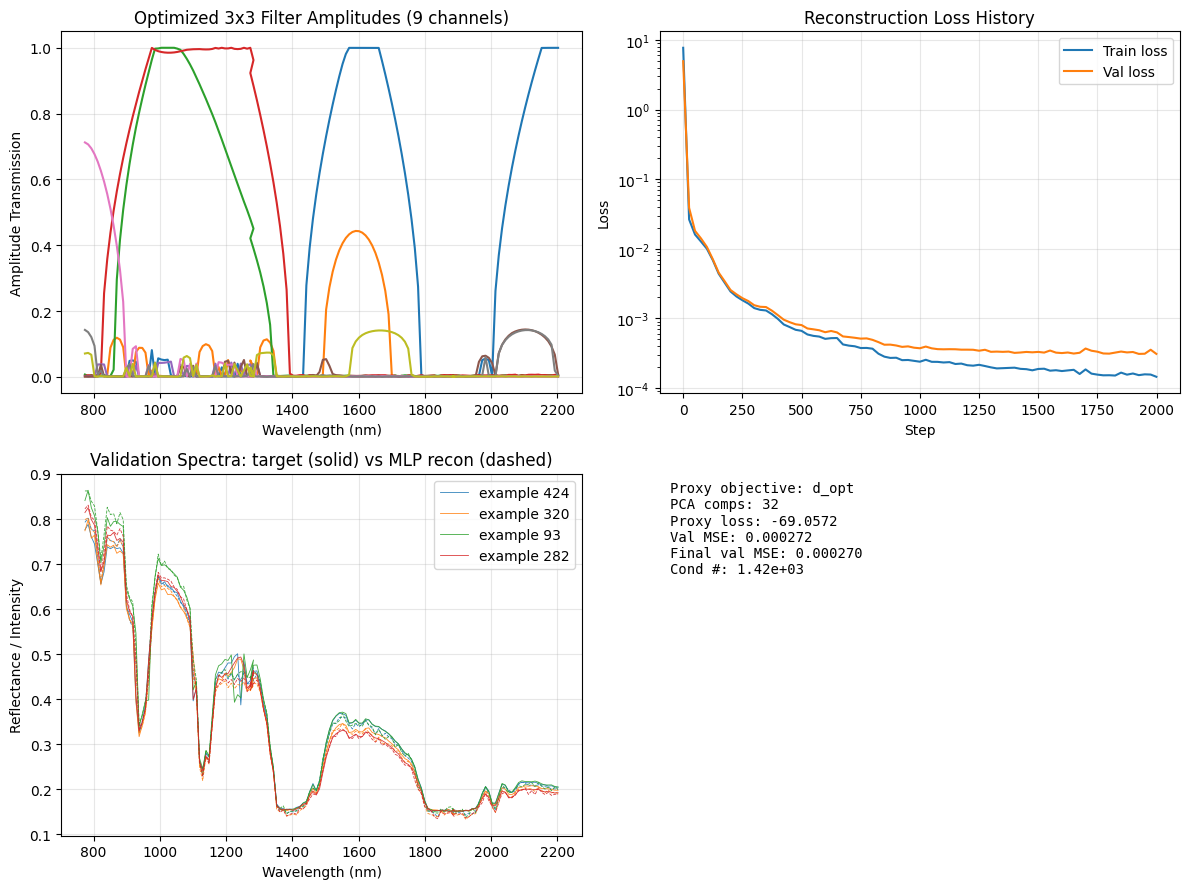

saved: artifacts/spectral_filter_example_overview.png


In [ ]:

import matplotlib.pyplot as plt

svals = np.linalg.svd(a_opt, compute_uv=False)
wavelengths_np = np.asarray(wavelengths_nm)
n_examples = min(4, val.shape[0])
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for i in range(num_filters):
    axes[0, 0].plot(wavelengths_np, filt_amp_opt[i], linewidth=1.5)
axes[0, 0].set_title(f"Optimized {array_size}x{array_size} Filter Amplitudes ({num_filters} channels)")
axes[0, 0].set_xlabel("Wavelength (nm)")
axes[0, 0].set_ylabel("Amplitude Transmission")
axes[0, 0].grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(history_steps, history_train, label="Train loss")
ax.plot(history_steps, history_val, label="Val loss")
ax.set_title("Reconstruction Loss History")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3)
ax.legend(loc="best")
ax.set_yscale("log")

random_indices = jax.random.choice(key, val.shape[0], (n_examples,), replace=False)
for i in random_indices:
    idx = int(i)
    (line,) = axes[1, 0].plot(wavelengths_np, val[idx], alpha=0.9, linewidth=0.6, label=f"example {idx}")
    axes[1, 0].plot(
        wavelengths_np,
        np.asarray(final_x_val_hat[idx]),
        alpha=0.9,
        linewidth=0.6,
        linestyle="--",
        color=line.get_color(),
    )
axes[1, 0].set_title("Validation Spectra: target (solid) vs MLP recon (dashed)")
axes[1, 0].set_xlabel("Wavelength (nm)")
axes[1, 0].set_ylabel("Reflectance / Intensity")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].axis("off")
axes[1, 1].text(
    0.02,
    0.98,
    (
        f"Proxy objective: d_opt\n"
        f"PCA comps: {pca_components}\n"
        f"Proxy loss: {best_proxy_loss:.4f}\n"
        f"Val MSE: {val_mse:.6f}\n"
        f"Final val MSE: {final_val_mse:.6f}\n"
        f"Cond #: {float(svals[0] / max(svals[-1], 1e-12)):.2e}"
    ),
    va="top",
    ha="left",
    fontsize=10,
    family="monospace",
)

out_dir = Path("artifacts")
out_dir.mkdir(parents=True, exist_ok=True)
plot_path = out_dir / "spectral_filter_example_overview.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=600)
plt.show()
print(f"saved: {plot_path}")
